In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_ollama import ChatOllama
from langchain.messages import RemoveMessage

In [2]:
model = ChatOllama(model="phi3")


In [3]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [4]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [5]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [6]:
graph = builder.compile(checkpointer=InMemorySaver())


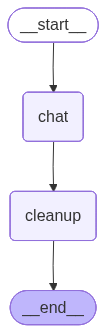

In [7]:
graph


In [8]:
config = {"configurable": {"thread_id": "t1"}}


In [9]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='0262a2aa-f8da-439e-8060-835f69839678'),
  AIMessage(content='"Langchain," as with "LangGraph," doesn\'t directly correspond to a known term in my database up until my last update. It could potentially be an acronym or name for various initiatives, tools, or projects related to language processing and development that are not widely recognized yet (as of the time I was updated).\n\nGiven your interest seems academic-related based on previous discussions about checkpoints in linguistic studies software, you might refer to a "Language Learning Chain"—a theoretical sequence where learners progressively build upon language skills through systematic and connected stages. Alternatively, it could be an innovative tool or method designed for chaining dialogues or tasks within Natural Language Processing (NLP) frameworks to facilitate more organic interactions with AI-driven conversational age

In [10]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
